# Part 4: Statistical Arbitrage Overlay
**Precog Quant Task 2026**

This notebook covers:
1. Correlation analysis across assets
2. Cointegration testing (Engle-Granger)
3. Lead-lag relationship discovery
4. Pairs trading signal design
5. Visual analysis of identified pairs
6. Implementation idea for integrating stat-arb into the main portfolio

> *"Oftentimes, there exist assets that exhibit correlated or cointegrated movement. Your goal is to find examples and explain the rationale."*


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from statsmodels.tsa.stattools import coint, adfuller
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
sns.set_style("whitegrid")

print("Libraries loaded.")


Libraries loaded.


## 1. Load Data

In [2]:
data = pd.read_csv("../data/cleaned_panel_data.csv", parse_dates=["Date"])
data = data.sort_values(["ticker", "Date"]).reset_index(drop=True)

# Create price pivot table (tickers as columns, dates as rows)
price_pivot = data.pivot_table(index="Date", columns="ticker", values="Close")
returns_pivot = data.pivot_table(index="Date", columns="ticker", values="log_ret_1d")

# Drop any assets with too many missing values
missing_pct = price_pivot.isnull().mean()
valid_tickers = missing_pct[missing_pct < 0.05].index.tolist()
price_pivot = price_pivot[valid_tickers].dropna()
returns_pivot = returns_pivot[valid_tickers].dropna()

print(f"Assets with sufficient data: {len(valid_tickers)}")
print(f"Date range: {price_pivot.index.min().date()} to {price_pivot.index.max().date()}")
print(f"Trading days: {len(price_pivot)}")


Assets with sufficient data: 100
Date range: 2016-04-20 to 2026-01-09
Trading days: 2429


## 2. Correlation Analysis

We start with the simplest measure — Pearson and Spearman correlation of returns — as a baseline.

**Important**: Correlation measures co-movement at the same time, but doesn't tell us about:
- Direction of causality (lead-lag)
- Mean-reverting spreads (cointegration)
- Time-varying relationships


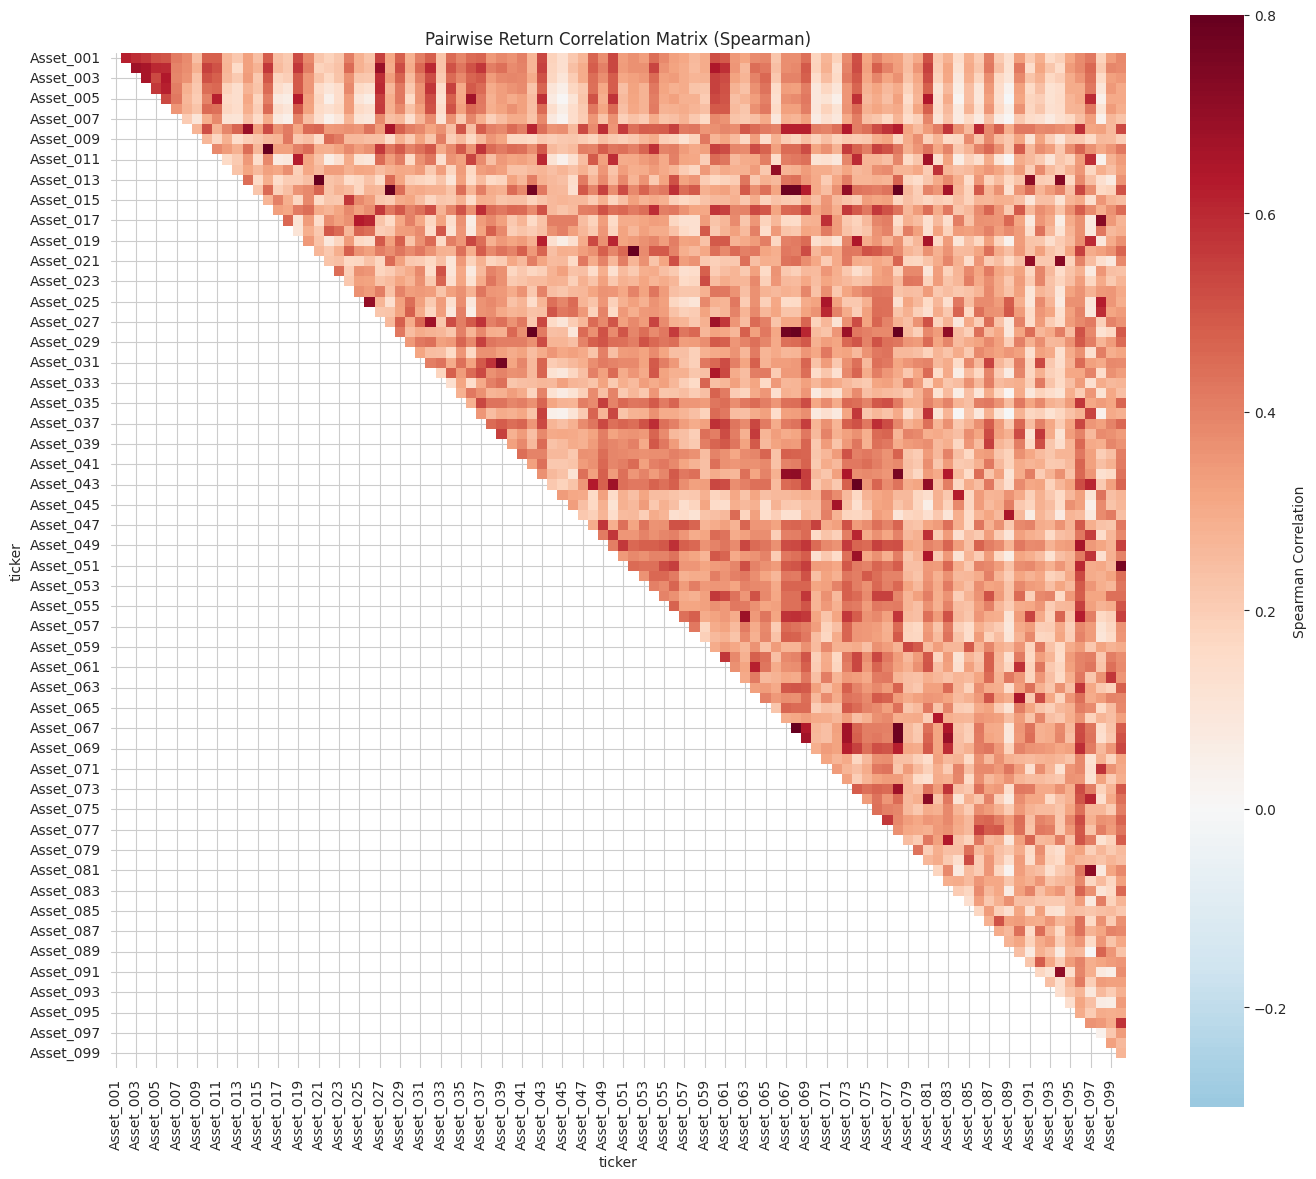

In [3]:
# Compute full return correlation matrix
corr_matrix = returns_pivot.corr(method="spearman")

# Visualize
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=~mask, cmap="RdBu_r", center=0, vmin=-0.3, vmax=0.8,
            square=True, linewidths=0, cbar_kws={"label": "Spearman Correlation"})
plt.title("Pairwise Return Correlation Matrix (Spearman)")
plt.tight_layout()
plt.savefig("../outputs/correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


In [4]:
# Find the most correlated pairs
pairs_corr = []
tickers = corr_matrix.columns.tolist()
for i in range(len(tickers)):
    for j in range(i+1, len(tickers)):
        pairs_corr.append({
            "Asset_A": tickers[i],
            "Asset_B": tickers[j],
            "Spearman_Corr": corr_matrix.iloc[i, j]
        })

pairs_df = pd.DataFrame(pairs_corr).sort_values("Spearman_Corr", ascending=False)

print("=== Top 15 Most Correlated Pairs ===")
print(pairs_df.head(15).to_string(index=False))
print()
print("=== Top 10 Most Negatively Correlated Pairs ===")
print(pairs_df.tail(10).to_string(index=False))


=== Top 15 Most Correlated Pairs ===
  Asset_A   Asset_B  Spearman_Corr
Asset_010 Asset_016       0.862643
Asset_014 Asset_028       0.849270
Asset_067 Asset_068       0.846502
Asset_028 Asset_078       0.829192
Asset_013 Asset_021       0.828119
Asset_043 Asset_074       0.827523
Asset_020 Asset_052       0.812105
Asset_014 Asset_078       0.810548
Asset_028 Asset_042       0.798242
Asset_028 Asset_068       0.789222
Asset_014 Asset_067       0.781328
Asset_014 Asset_068       0.780836
Asset_068 Asset_078       0.780231
Asset_067 Asset_078       0.778828
Asset_014 Asset_042       0.773873

=== Top 10 Most Negatively Correlated Pairs ===
  Asset_A   Asset_B  Spearman_Corr
Asset_007 Asset_045       0.028159
Asset_005 Asset_084       0.021273
Asset_034 Asset_089       0.014081
Asset_011 Asset_089       0.010300
Asset_007 Asset_089       0.009503
Asset_005 Asset_045       0.009326
Asset_036 Asset_084       0.007070
Asset_089 Asset_097       0.002672
Asset_036 Asset_089      -0.005332
Asse

## 3. Rolling Correlation

Correlations are not static. We look at how the top pairs' correlation evolves over time.


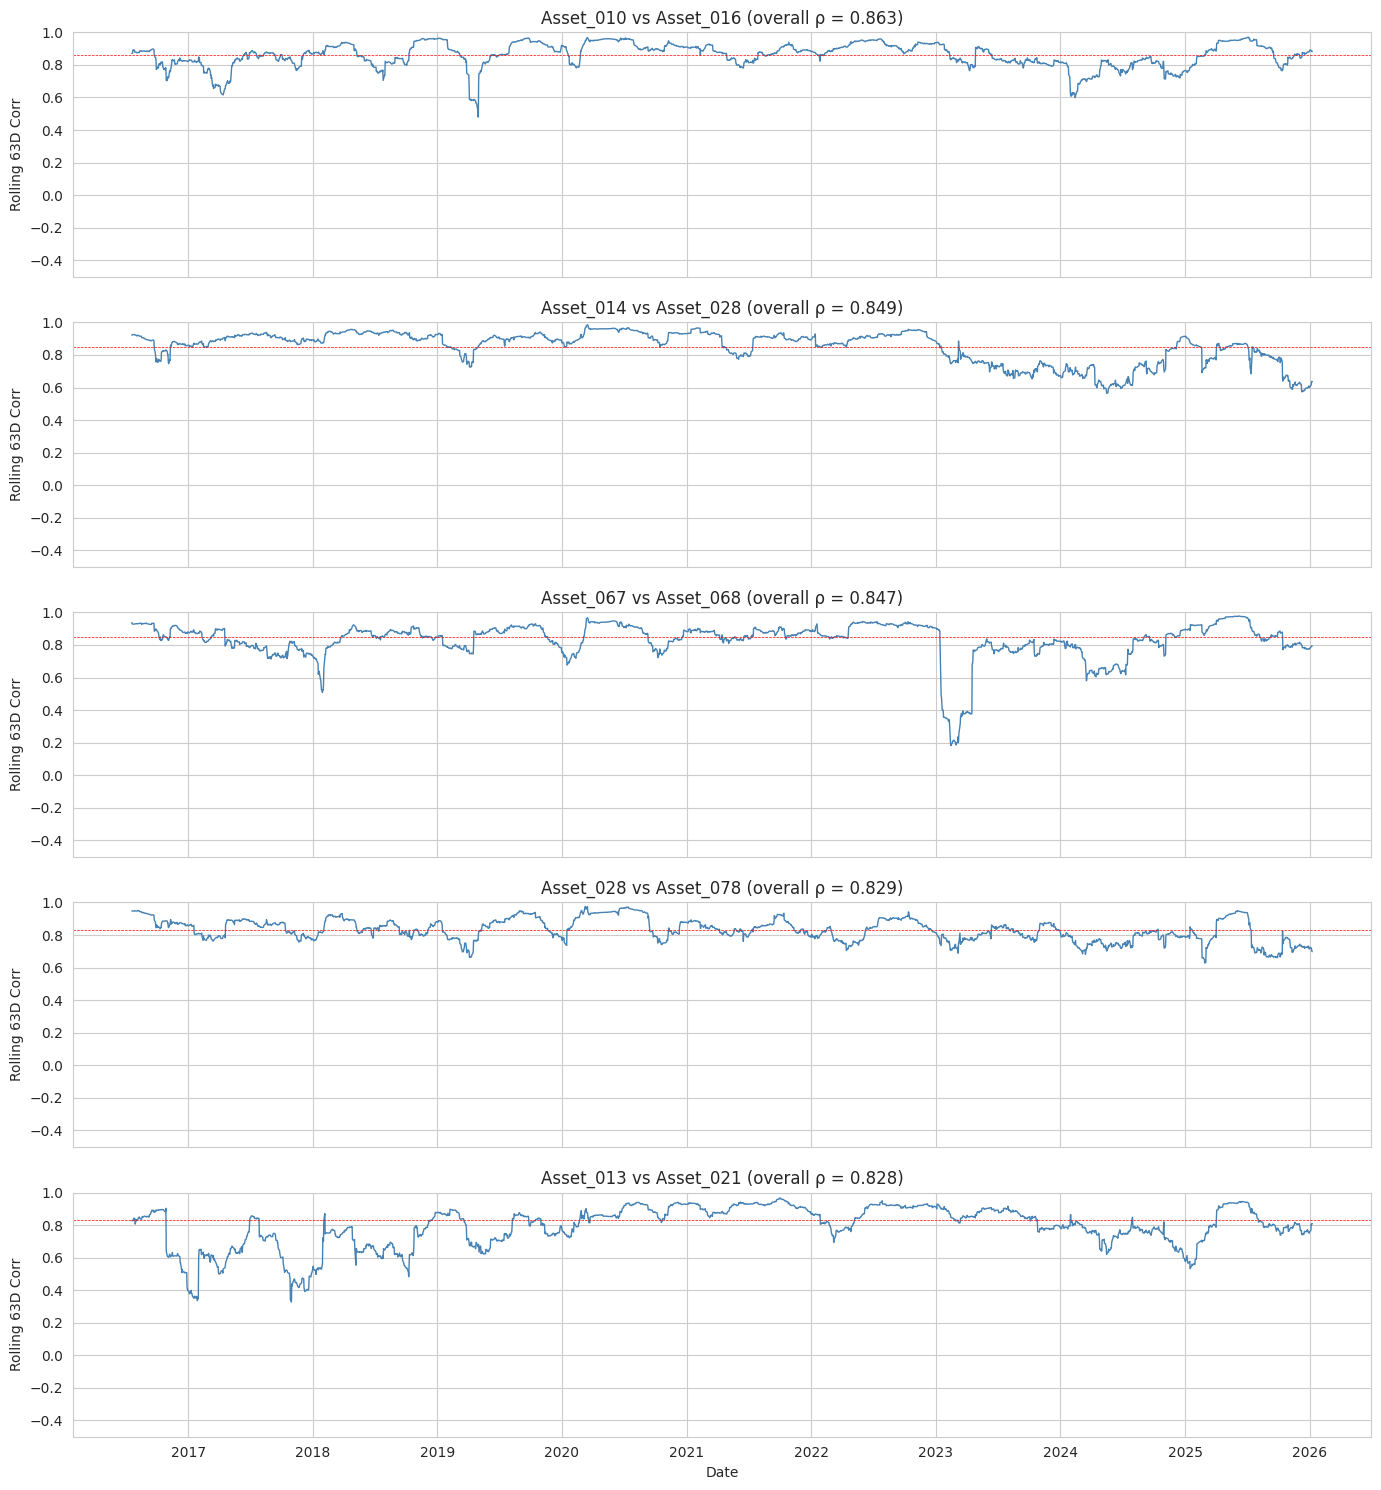

In [5]:
# Top 5 correlated pairs — rolling correlation
top_pairs = pairs_df.head(5)

fig, axes = plt.subplots(5, 1, figsize=(14, 15), sharex=True)

for idx, (_, row) in enumerate(top_pairs.iterrows()):
    a, b = row["Asset_A"], row["Asset_B"]
    rolling_corr = returns_pivot[a].rolling(63).corr(returns_pivot[b])
    
    axes[idx].plot(rolling_corr.index, rolling_corr.values, linewidth=1, color="steelblue")
    axes[idx].axhline(row["Spearman_Corr"], color="red", linewidth=0.5, linestyle="--")
    axes[idx].set_title(f"{a} vs {b} (overall ρ = {row['Spearman_Corr']:.3f})")
    axes[idx].set_ylabel("Rolling 63D Corr")
    axes[idx].set_ylim(-0.5, 1.0)

plt.xlabel("Date")
plt.tight_layout()
plt.savefig("../outputs/rolling_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Cointegration Analysis

**Correlation ≠ Cointegration.** Two assets can be highly correlated but not cointegrated, and vice versa.

- **Correlation** measures linear association of returns (short-term)
- **Cointegration** measures whether a linear combination of price levels is stationary (long-run equilibrium)

If assets A and B are cointegrated, the spread $S_t = P_A(t) - \beta \cdot P_B(t)$ is mean-reverting — the basis of pairs trading.

We use the **Engle-Granger** two-step test:
1. Regress log-prices: $\log P_A = \alpha + \beta \cdot \log P_B + \epsilon$
2. Test if residuals $\epsilon$ are stationary (ADF test)


In [6]:
# Run cointegration test on all pairs (computationally intensive — sample top candidates)
# Pre-filter: only test pairs with correlation > 0.5 (reduces computation dramatically)
candidate_pairs = pairs_df[pairs_df["Spearman_Corr"] > 0.5].copy()
print(f"Testing {len(candidate_pairs)} candidate pairs for cointegration...")

log_prices = np.log(price_pivot)

coint_results = []
for _, row in candidate_pairs.iterrows():
    a, b = row["Asset_A"], row["Asset_B"]
    try:
        score, pvalue, _ = coint(log_prices[a], log_prices[b])
        coint_results.append({
            "Asset_A": a,
            "Asset_B": b,
            "Corr": row["Spearman_Corr"],
            "Coint_Score": score,
            "Coint_PValue": pvalue,
            "Cointegrated_5pct": pvalue < 0.05,
        })
    except Exception:
        pass

coint_df = pd.DataFrame(coint_results).sort_values("Coint_PValue")
print(f"\nCointegrated pairs (p < 0.05): {coint_df['Cointegrated_5pct'].sum()} out of {len(coint_df)}")
print()
print("=== Top 15 Most Cointegrated Pairs ===")
print(coint_df.head(15).to_string(index=False))


Testing 353 candidate pairs for cointegration...



Cointegrated pairs (p < 0.05): 33 out of 353

=== Top 15 Most Cointegrated Pairs ===
  Asset_A   Asset_B     Corr  Coint_Score  Coint_PValue  Cointegrated_5pct
Asset_031 Asset_039 0.764592    -5.023817      0.000149               True
Asset_002 Asset_036 0.510428    -4.804923      0.000370               True
Asset_043 Asset_060 0.529875    -4.240496      0.003165               True
Asset_004 Asset_032 0.568043    -4.133943      0.004583               True
Asset_035 Asset_077 0.513808    -4.113496      0.004914               True
Asset_003 Asset_081 0.517720    -3.971464      0.007883               True
Asset_008 Asset_086 0.598973    -3.884444      0.010421               True
Asset_049 Asset_051 0.562173    -3.871191      0.010865               True
Asset_035 Asset_096 0.568497    -3.848394      0.011670               True
Asset_037 Asset_043 0.528509    -3.766401      0.015019               True
Asset_002 Asset_074 0.524210    -3.746636      0.015944               True
Asset_052 Asse

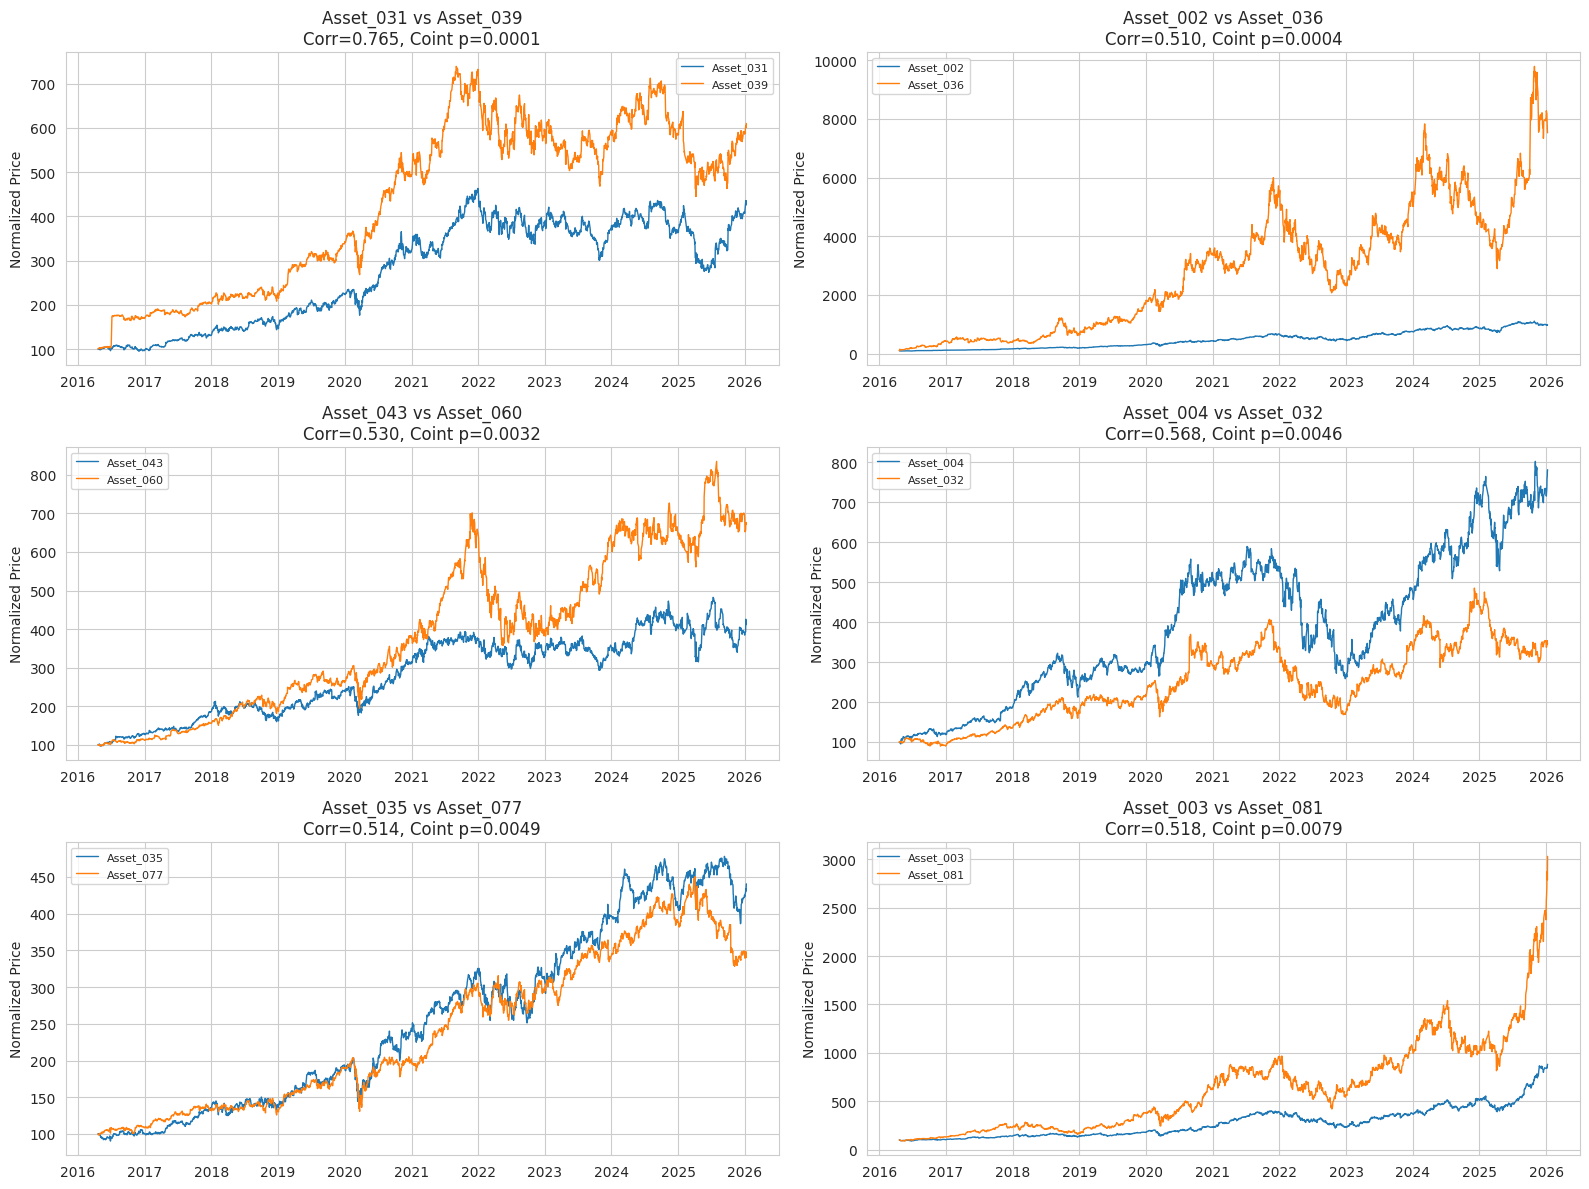

In [7]:
# Visualize top cointegrated pairs
top_coint = coint_df.head(6)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flat

for idx, (_, row) in enumerate(top_coint.iterrows()):
    a, b = row["Asset_A"], row["Asset_B"]
    
    # Normalize prices to start at 100 for visual comparison
    norm_a = price_pivot[a] / price_pivot[a].iloc[0] * 100
    norm_b = price_pivot[b] / price_pivot[b].iloc[0] * 100
    
    axes[idx].plot(norm_a.index, norm_a.values, label=a, linewidth=1)
    axes[idx].plot(norm_b.index, norm_b.values, label=b, linewidth=1)
    axes[idx].set_title(f"{a} vs {b}\nCorr={row['Corr']:.3f}, Coint p={row['Coint_PValue']:.4f}")
    axes[idx].legend(fontsize=8)
    axes[idx].set_ylabel("Normalized Price")

plt.tight_layout()
plt.savefig("../outputs/cointegrated_pairs.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Spread Analysis for Top Cointegrated Pairs

For a cointegrated pair, we construct the spread and analyze its mean-reverting behavior.

$$\text{Spread}_t = \log P_A(t) - \beta \cdot \log P_B(t)$$

where $\beta$ is the OLS hedge ratio.


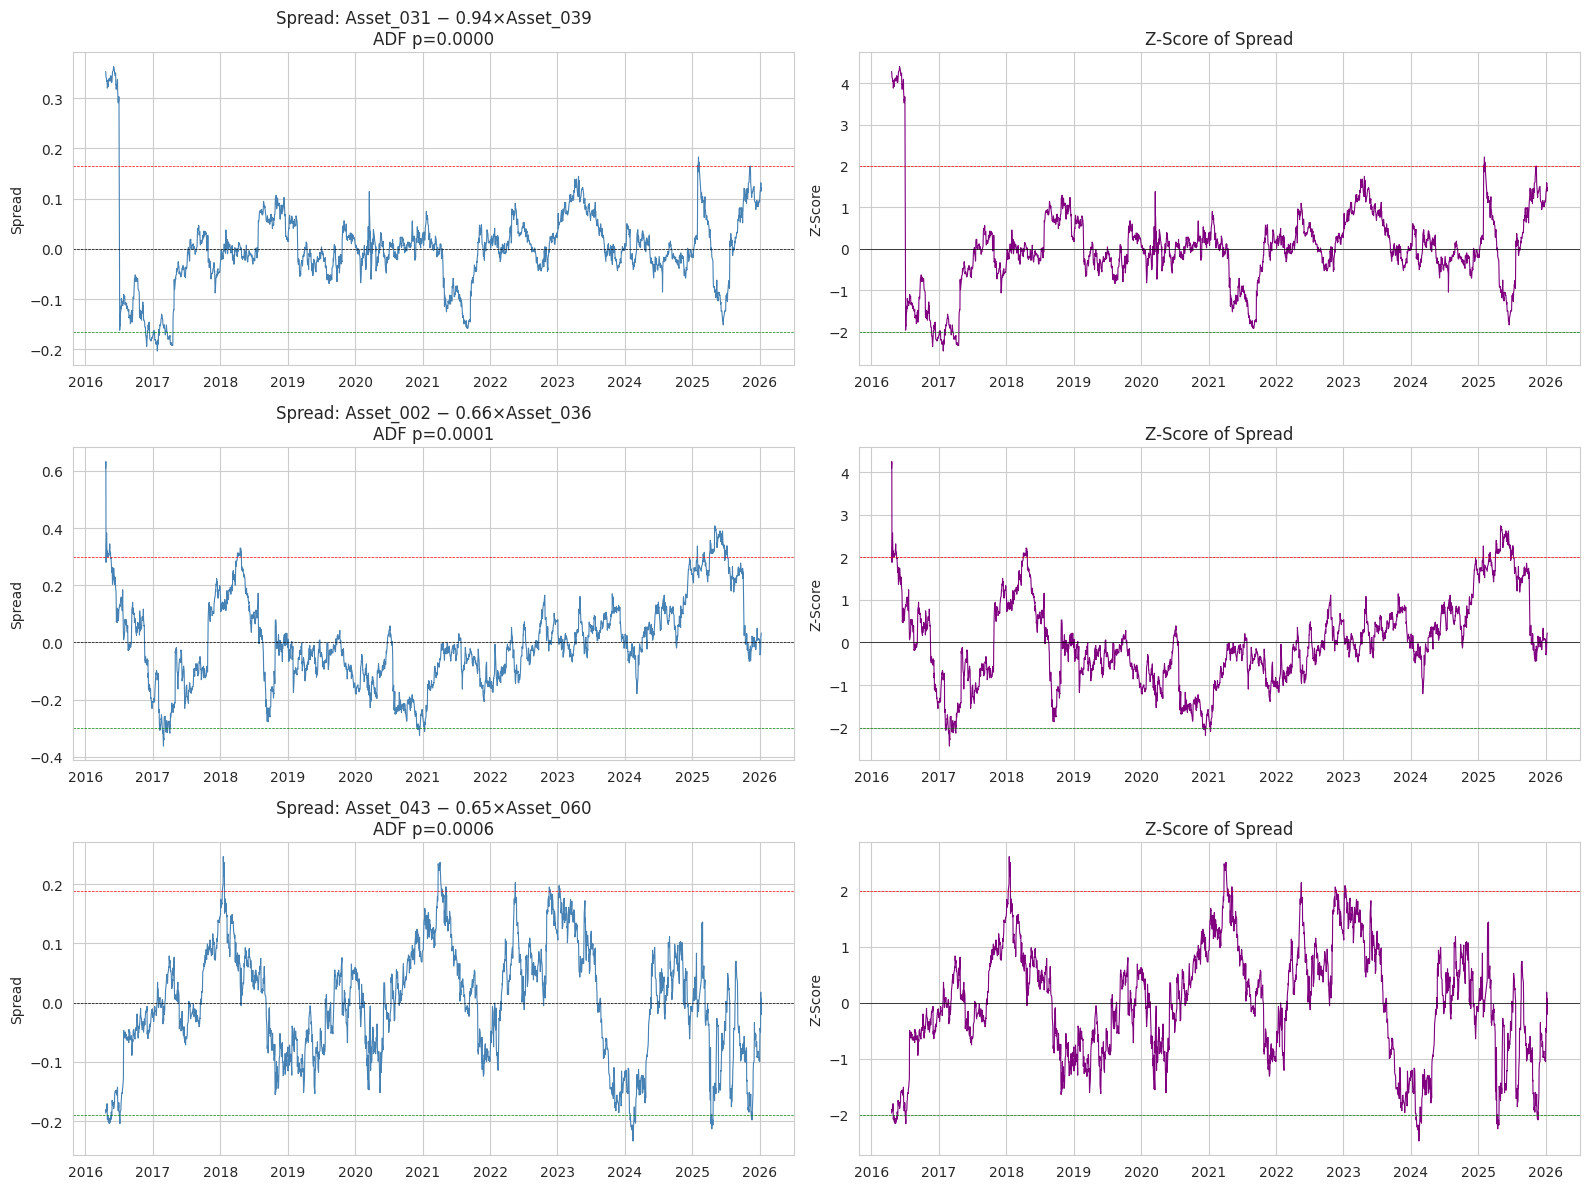

In [8]:
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# Analyze top 3 cointegrated pairs
top3 = coint_df.head(3)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for idx, (_, row) in enumerate(top3.iterrows()):
    a, b = row["Asset_A"], row["Asset_B"]
    
    # OLS regression to get hedge ratio
    y = log_prices[a].values
    X = add_constant(log_prices[b].values)
    model = OLS(y, X).fit()
    beta = model.params[1]
    alpha = model.params[0]
    
    # Spread
    spread = log_prices[a] - beta * log_prices[b] - alpha
    spread_mean = spread.mean()
    spread_std = spread.std()
    z_score = (spread - spread_mean) / spread_std
    
    # ADF test on spread
    adf_stat, adf_pval, _, _, _, _ = adfuller(spread.values)
    
    # Plot spread
    axes[idx, 0].plot(spread.index, spread.values, linewidth=0.8, color="steelblue")
    axes[idx, 0].axhline(spread_mean, color="black", linewidth=0.5, linestyle="--")
    axes[idx, 0].axhline(spread_mean + 2*spread_std, color="red", linewidth=0.5, linestyle="--")
    axes[idx, 0].axhline(spread_mean - 2*spread_std, color="green", linewidth=0.5, linestyle="--")
    axes[idx, 0].set_title(f"Spread: {a} − {beta:.2f}×{b}\nADF p={adf_pval:.4f}")
    axes[idx, 0].set_ylabel("Spread")
    
    # Plot z-score
    axes[idx, 1].plot(z_score.index, z_score.values, linewidth=0.8, color="purple")
    axes[idx, 1].axhline(0, color="black", linewidth=0.5)
    axes[idx, 1].axhline(2, color="red", linewidth=0.5, linestyle="--")
    axes[idx, 1].axhline(-2, color="green", linewidth=0.5, linestyle="--")
    axes[idx, 1].set_title(f"Z-Score of Spread")
    axes[idx, 1].set_ylabel("Z-Score")

plt.tight_layout()
plt.savefig("../outputs/spread_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Lead-Lag Relationship Analysis

Beyond simultaneous co-movement, we investigate whether any asset **leads** another — i.e., today's return of Asset A predicts tomorrow's return of Asset B.

We compute cross-correlation at various lags and identify significant lead-lag relationships.


In [9]:
# Cross-correlation function at multiple lags
MAX_LAG = 5  # Up to 5 trading days
top_corr_pairs = pairs_df.head(20)  # Test top 20 correlated pairs

lead_lag_results = []
for _, row in top_corr_pairs.iterrows():
    a, b = row["Asset_A"], row["Asset_B"]
    ret_a = returns_pivot[a].dropna()
    ret_b = returns_pivot[b].dropna()
    
    # Align
    common_idx = ret_a.index.intersection(ret_b.index)
    ret_a = ret_a.loc[common_idx]
    ret_b = ret_b.loc[common_idx]
    
    for lag in range(-MAX_LAG, MAX_LAG + 1):
        if lag == 0:
            continue
        if lag > 0:
            # A leads B by 'lag' days
            cc = ret_a.iloc[:-lag].corr(ret_b.iloc[lag:])
            direction = f"{a} leads {b}"
        else:
            # B leads A by 'lag' days
            cc = ret_b.iloc[:lag].corr(ret_a.iloc[-lag:])
            direction = f"{b} leads {a}"
        
        lead_lag_results.append({
            "Asset_A": a,
            "Asset_B": b,
            "Lag": lag,
            "Direction": direction,
            "Cross_Corr": cc,
            "Abs_Cross_Corr": abs(cc),
        })

ll_df = pd.DataFrame(lead_lag_results).sort_values("Abs_Cross_Corr", ascending=False)

# Significance threshold (rough): |r| > 2/sqrt(N)
n_obs = len(common_idx)
sig_threshold = 2 / np.sqrt(n_obs)
ll_df["Significant"] = ll_df["Abs_Cross_Corr"] > sig_threshold

print(f"Significance threshold: {sig_threshold:.4f}")
print()
print("=== Top 15 Lead-Lag Relationships ===")
print(ll_df.head(15)[["Asset_A", "Asset_B", "Lag", "Direction", "Cross_Corr", "Significant"]].to_string(index=False))


Significance threshold: 0.0406

=== Top 15 Lead-Lag Relationships ===
  Asset_A   Asset_B  Lag                 Direction  Cross_Corr  Significant
Asset_010 Asset_016   -5 Asset_016 leads Asset_010    0.900673         True
Asset_010 Asset_016    5 Asset_010 leads Asset_016    0.900673         True
Asset_010 Asset_016    4 Asset_010 leads Asset_016    0.900581         True
Asset_010 Asset_016   -4 Asset_016 leads Asset_010    0.900581         True
Asset_010 Asset_016   -3 Asset_016 leads Asset_010    0.900524         True
Asset_010 Asset_016    3 Asset_010 leads Asset_016    0.900524         True
Asset_010 Asset_016    2 Asset_010 leads Asset_016    0.900200         True
Asset_010 Asset_016   -2 Asset_016 leads Asset_010    0.900200         True
Asset_010 Asset_016   -1 Asset_016 leads Asset_010    0.900118         True
Asset_010 Asset_016    1 Asset_010 leads Asset_016    0.900118         True
Asset_014 Asset_028   -2 Asset_028 leads Asset_014    0.884352         True
Asset_014 Asset_02

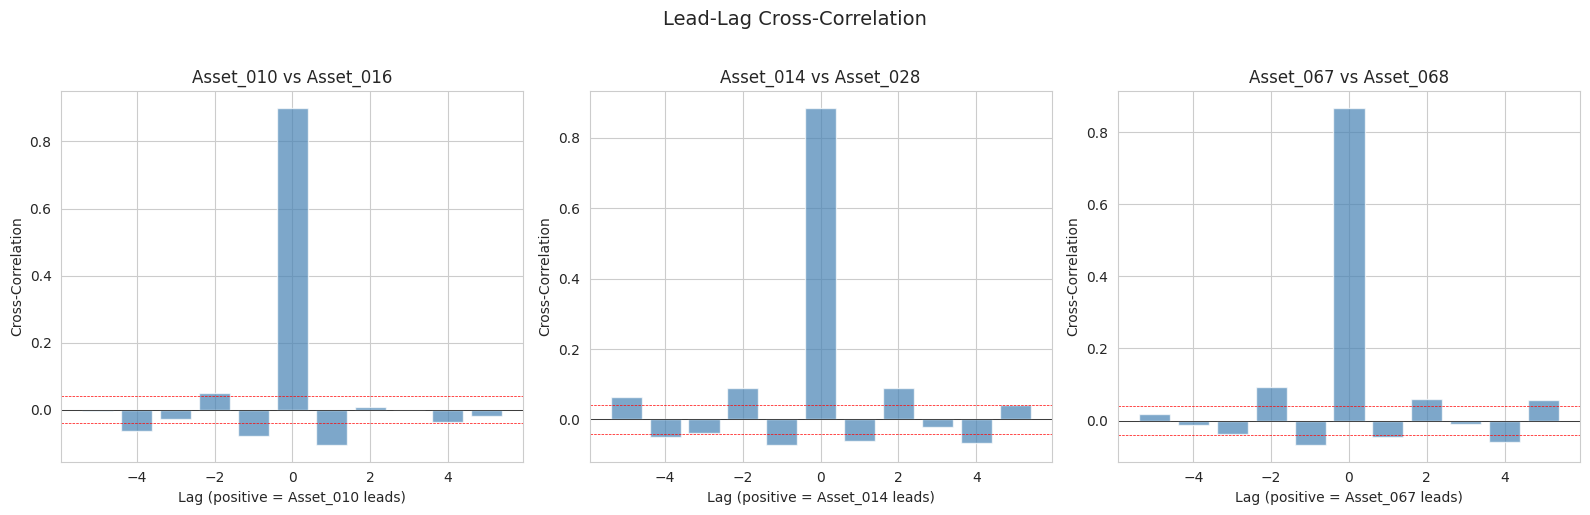

In [10]:
# Visualize cross-correlation for top 3 pairs
top_ll_pairs = ll_df.drop_duplicates(subset=["Asset_A", "Asset_B"]).head(3)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (_, row) in enumerate(top_ll_pairs.iterrows()):
    a, b = row["Asset_A"], row["Asset_B"]
    
    lags = range(-MAX_LAG, MAX_LAG + 1)
    cc_vals = []
    for lag in lags:
        ret_a = returns_pivot[a].dropna()
        ret_b = returns_pivot[b].dropna()
        common_idx = ret_a.index.intersection(ret_b.index)
        ret_a = ret_a.loc[common_idx]
        ret_b = ret_b.loc[common_idx]
        
        if lag == 0:
            cc_vals.append(ret_a.corr(ret_b))
        elif lag > 0:
            cc_vals.append(ret_a.iloc[:-lag].reset_index(drop=True).corr(
                ret_b.iloc[lag:].reset_index(drop=True)))
        else:
            cc_vals.append(ret_b.iloc[:-abs(lag)].reset_index(drop=True).corr(
                ret_a.iloc[abs(lag):].reset_index(drop=True)))
    
    axes[idx].bar(lags, cc_vals, color="steelblue", alpha=0.7)
    axes[idx].axhline(sig_threshold, color="red", linewidth=0.5, linestyle="--")
    axes[idx].axhline(-sig_threshold, color="red", linewidth=0.5, linestyle="--")
    axes[idx].axhline(0, color="black", linewidth=0.5)
    axes[idx].set_title(f"{a} vs {b}")
    axes[idx].set_xlabel(f"Lag (positive = {a} leads)")
    axes[idx].set_ylabel("Cross-Correlation")

plt.suptitle("Lead-Lag Cross-Correlation", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/lead_lag.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Sector/Cluster Analysis via PCA

Since the assets are anonymized, we can't directly identify sectors. However, we can use **PCA** to discover latent factors that group assets together — these may correspond to sectors, themes, or risk factors.


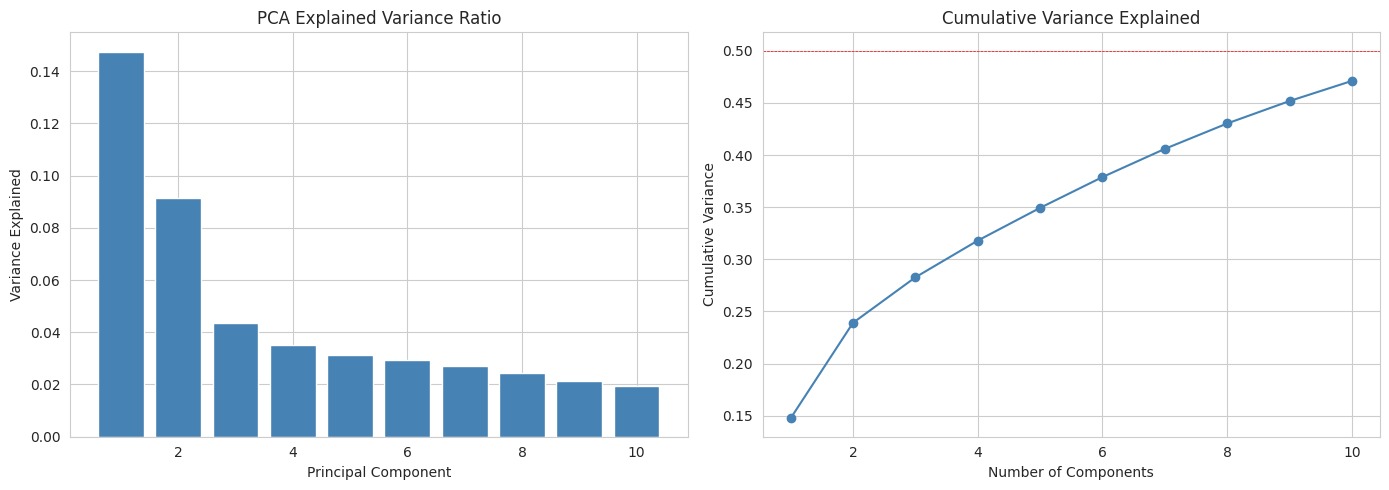

Variance explained by first 3 PCs: 28.3%
Variance explained by first 5 PCs: 34.9%


In [11]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# PCA on return correlations
ret_clean = returns_pivot.dropna(axis=1)
pca = PCA(n_components=10)
pca.fit(ret_clean.T)  # Transpose: assets as observations, days as features

# Explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 11), pca.explained_variance_ratio_, color="steelblue")
axes[0].set_title("PCA Explained Variance Ratio")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance Explained")

axes[1].plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_), 
             marker="o", color="steelblue")
axes[1].set_title("Cumulative Variance Explained")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Variance")
axes[1].axhline(0.5, color="red", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.savefig("../outputs/pca_variance.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Variance explained by first 3 PCs: {pca.explained_variance_ratio_[:3].sum():.1%}")
print(f"Variance explained by first 5 PCs: {pca.explained_variance_ratio_[:5].sum():.1%}")


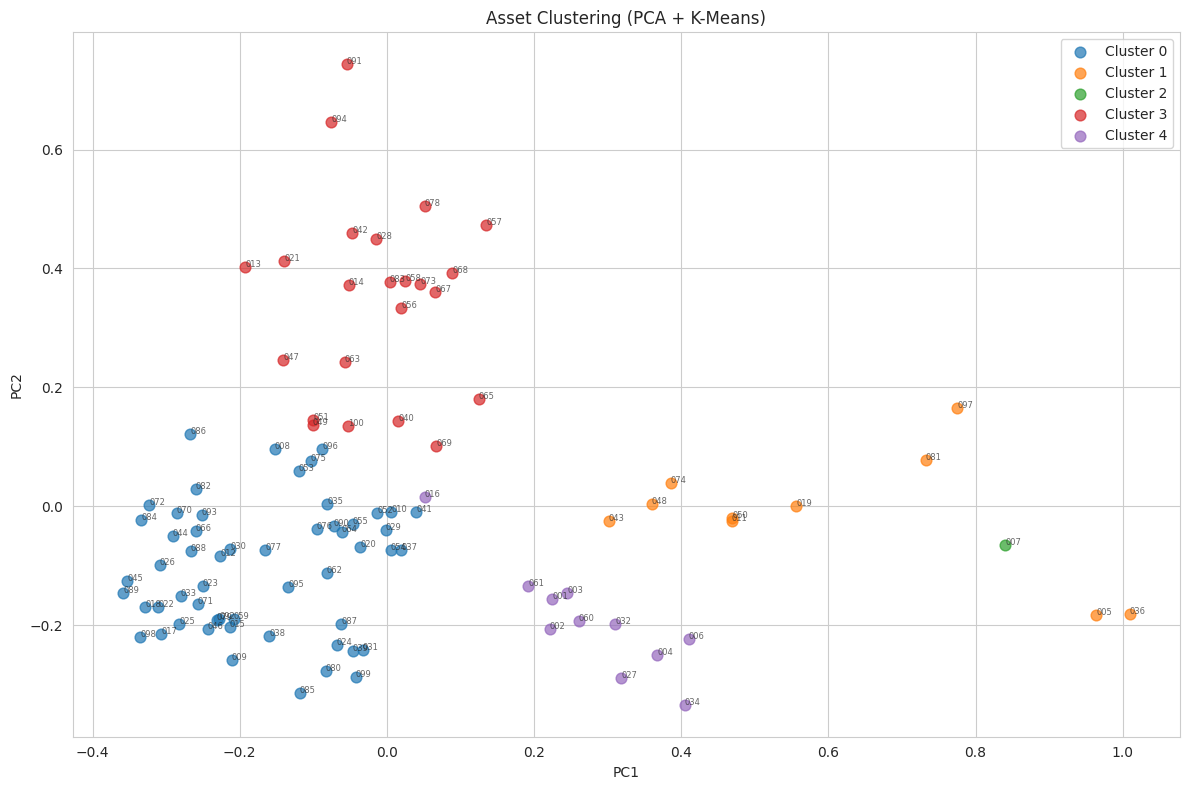

Cluster 0 (55 assets): 008, 009, 010, 012, 015, 017, 018, 020, 022, 023, 024, 025, 026, 029, 030, 031, 033, 035, 037, 038, 039, 041, 044, 045, 046, 052, 053, 054, 055, 059, 062, 064, 066, 070, 071, 072, 075, 076, 077, 079, 080, 082, 084, 085, 086, 087, 088, 089, 090, 092, 093, 095, 096, 098, 099
Cluster 1 (10 assets): 005, 011, 019, 036, 043, 048, 050, 074, 081, 097
Cluster 2 (1 assets): 007
Cluster 3 (23 assets): 013, 014, 021, 028, 040, 042, 047, 049, 051, 056, 057, 058, 063, 065, 067, 068, 069, 073, 078, 083, 091, 094, 100
Cluster 4 (11 assets): 001, 002, 003, 004, 006, 016, 027, 032, 034, 060, 061


In [12]:
# Cluster assets using first 5 PCs
pc_scores = pca.transform(ret_clean.T)[:, :5]
asset_names = ret_clean.columns.tolist()

# K-Means clustering
N_CLUSTERS = 5
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
clusters = kmeans.fit_predict(pc_scores)

cluster_df = pd.DataFrame({
    "Asset": asset_names,
    "Cluster": clusters,
    "PC1": pc_scores[:, 0],
    "PC2": pc_scores[:, 1],
})

# Scatter plot
fig, ax = plt.subplots(figsize=(12, 8))
for c in range(N_CLUSTERS):
    mask = cluster_df["Cluster"] == c
    ax.scatter(cluster_df.loc[mask, "PC1"], cluster_df.loc[mask, "PC2"], 
               label=f"Cluster {c}", s=60, alpha=0.7)
    for _, r in cluster_df[mask].iterrows():
        ax.annotate(r["Asset"].replace("Asset_", ""), (r["PC1"], r["PC2"]), 
                    fontsize=6, alpha=0.7)

ax.set_title("Asset Clustering (PCA + K-Means)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/asset_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

# Print clusters
for c in range(N_CLUSTERS):
    assets = cluster_df[cluster_df["Cluster"] == c]["Asset"].tolist()
    print(f"Cluster {c} ({len(assets)} assets): {', '.join([a.replace('Asset_', '') for a in assets])}")


In [13]:
# Within-cluster vs between-cluster correlation
print("=== Average Correlation Within vs Between Clusters ===\n")

for c in range(N_CLUSTERS):
    cluster_assets = cluster_df[cluster_df["Cluster"] == c]["Asset"].tolist()
    other_assets = cluster_df[cluster_df["Cluster"] != c]["Asset"].tolist()
    
    if len(cluster_assets) < 2:
        continue
    
    within_corrs = []
    for i in range(len(cluster_assets)):
        for j in range(i+1, len(cluster_assets)):
            if cluster_assets[i] in corr_matrix.columns and cluster_assets[j] in corr_matrix.columns:
                within_corrs.append(corr_matrix.loc[cluster_assets[i], cluster_assets[j]])
    
    between_corrs = []
    for a in cluster_assets[:5]:  # sample
        for b in other_assets[:20]:  # sample
            if a in corr_matrix.columns and b in corr_matrix.columns:
                between_corrs.append(corr_matrix.loc[a, b])
    
    within_avg = np.mean(within_corrs) if within_corrs else 0
    between_avg = np.mean(between_corrs) if between_corrs else 0
    
    print(f"Cluster {c}: Within={within_avg:.3f}  Between={between_avg:.3f}  "
          f"Ratio={within_avg/between_avg:.2f}x  ({len(cluster_assets)} assets)")


=== Average Correlation Within vs Between Clusters ===

Cluster 0: Within=0.336  Between=0.290  Ratio=1.16x  (55 assets)
Cluster 1: Within=0.606  Between=0.309  Ratio=1.96x  (10 assets)
Cluster 3: Within=0.485  Between=0.273  Ratio=1.77x  (23 assets)
Cluster 4: Within=0.548  Between=0.300  Ratio=1.83x  (11 assets)


## 8. Pairs Trading Strategy — Conceptual Implementation

### How to integrate stat-arb into the main portfolio:

Given a cointegrated pair $(A, B)$ with hedge ratio $\beta$:

**Signal Construction:**
$$z_t = \frac{(\log P_A(t) - \beta \cdot \log P_B(t)) - \mu}{\sigma}$$

**Trading Rules:**
- **Enter long spread** when $z_t < -2$ (spread is cheap → buy A, sell βB)
- **Enter short spread** when $z_t > +2$ (spread is rich → sell A, buy βB)
- **Exit** when $z_t$ crosses 0 (spread reverts to mean)

**Integration with Main Portfolio:**
1. Run the main alpha model (Part 2) to generate directional signals
2. Overlay pairs signals as an additional alpha source
3. Combine using a weighting scheme:

$$w_i^{\text{final}} = \lambda \cdot w_i^{\text{directional}} + (1-\lambda) \cdot w_i^{\text{pairs}}$$

where $\lambda \in [0.7, 0.9]$ (directional model gets more weight since it's trained on all assets).

**Key Considerations:**
- The hedge ratio $\beta$ should be estimated on a rolling window (not static)
- The spread's half-life determines the holding period: $t_{1/2} = \frac{\ln(2)}{-\ln(\phi)}$ where $\phi$ is the AR(1) coefficient
- Position sizing should be inversely proportional to spread volatility
- Stop-losses at $|z| > 4$ to protect against regime breaks


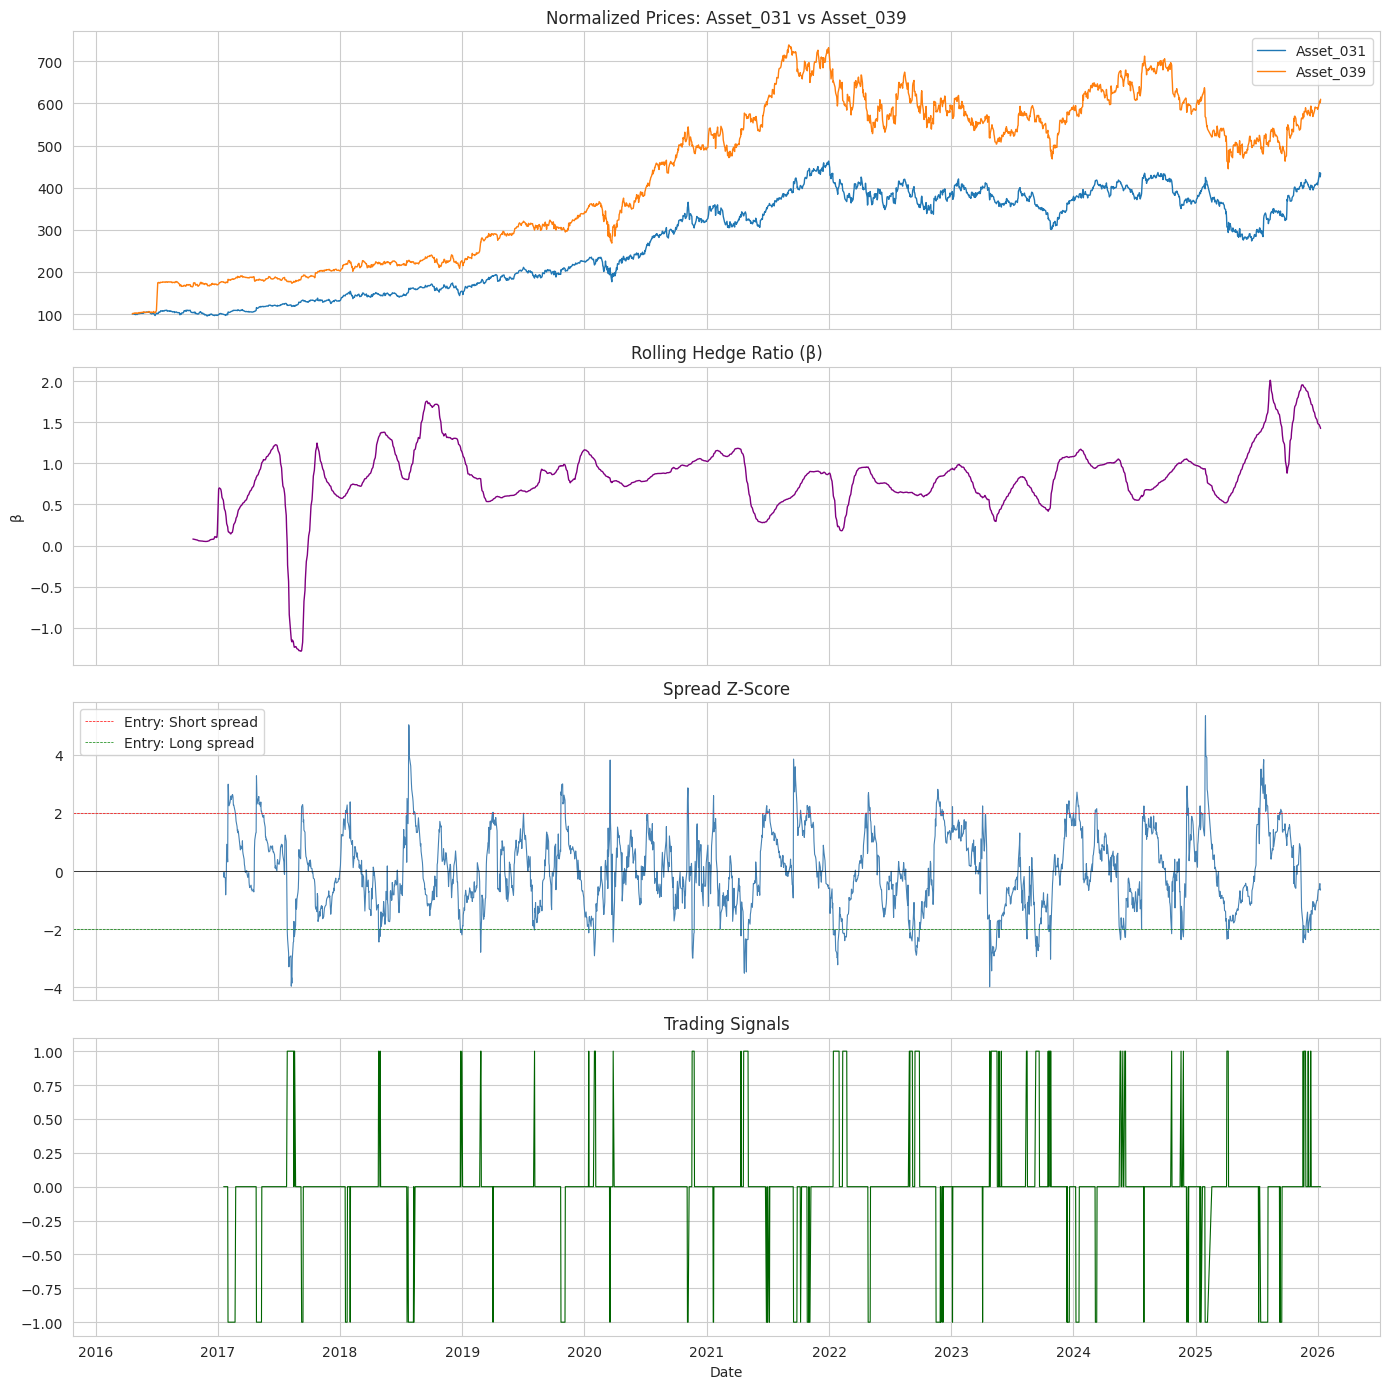


Best pair: Asset_031 vs Asset_039
Cointegration p-value: 0.000149
Estimated half-life: 23.7 days
Number of entry signals: 283


In [14]:
# Demonstrate pairs trading signals for the best cointegrated pair
data["stat_arb_pos"] = 0.0
if len(coint_df) > 0:
    best_pair = coint_df.iloc[0]
    a, b = best_pair["Asset_A"], best_pair["Asset_B"]
    
    # Rolling hedge ratio (use 126-day rolling OLS)
    WINDOW = 126
    spreads = pd.Series(index=log_prices.index, dtype=float)
    betas = pd.Series(index=log_prices.index, dtype=float)
    
    for i in range(WINDOW, len(log_prices)):
        y = log_prices[a].iloc[i-WINDOW:i].values
        x = log_prices[b].iloc[i-WINDOW:i].values
        x_const = np.column_stack([np.ones(WINDOW), x])
        params = np.linalg.lstsq(x_const, y, rcond=None)[0]
        alpha_coef, beta_coef = params
        
        date = log_prices.index[i]
        betas.loc[date] = beta_coef
        spreads.loc[date] = log_prices[a].iloc[i] - beta_coef * log_prices[b].iloc[i] - alpha_coef
    
    spreads = spreads.dropna()
    betas = betas.dropna()
    
    # Rolling z-score of spread
    spread_mean = spreads.rolling(63).mean()
    spread_std = spreads.rolling(63).std()
    z_spread = (spreads - spread_mean) / spread_std.replace(0, np.nan)
    z_spread = z_spread.dropna()
    
    # Generate signals
    signals = pd.Series(0.0, index=z_spread.index)
    signals[z_spread < -2] = 1.0    # Long spread (buy A, sell B)
    signals[z_spread > 2] = -1.0    # Short spread (sell A, buy B)
    
    fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
    
    # Normalized prices
    norm_a = price_pivot[a] / price_pivot[a].iloc[0] * 100
    norm_b = price_pivot[b] / price_pivot[b].iloc[0] * 100
    axes[0].plot(norm_a, label=a, linewidth=1)
    axes[0].plot(norm_b, label=b, linewidth=1)
    axes[0].set_title(f"Normalized Prices: {a} vs {b}")
    axes[0].legend()
    
    # Rolling hedge ratio
    axes[1].plot(betas, color="purple", linewidth=1)
    axes[1].set_title("Rolling Hedge Ratio (β)")
    axes[1].set_ylabel("β")
    
    # Z-score of spread
    axes[2].plot(z_spread, color="steelblue", linewidth=0.8)
    axes[2].axhline(2, color="red", linewidth=0.5, linestyle="--", label="Entry: Short spread")
    axes[2].axhline(-2, color="green", linewidth=0.5, linestyle="--", label="Entry: Long spread")
    axes[2].axhline(0, color="black", linewidth=0.5)
    axes[2].set_title("Spread Z-Score")
    axes[2].legend()
    
    # Signals
    axes[3].plot(signals, color="darkgreen", linewidth=0.8)
    axes[3].set_title("Trading Signals")
    axes[3].set_xlabel("Date")
    
    plt.tight_layout()
    plt.savefig("../outputs/pairs_trading_demo.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    # Half-life estimation
    spread_arr = spreads.values
    spread_lag = spread_arr[:-1]
    spread_diff = np.diff(spread_arr)
    beta_ar1 = np.polyfit(spread_lag, spread_diff, 1)[0]
    half_life = -np.log(2) / beta_ar1 if beta_ar1 < 0 else np.inf
    print(f"\nBest pair: {a} vs {b}")
    print(f"Cointegration p-value: {best_pair['Coint_PValue']:.6f}")
    print(f"Estimated half-life: {half_life:.1f} days")
    print(f"Number of entry signals: {(signals != 0).sum()}")
else:
    print("No cointegrated pairs found — this is not unusual in anonymized data.")


## 9. Multi-Timeframe Correlation Analysis

Assets may move together at different timeframes. Weekly correlation can differ significantly from daily correlation.


In [15]:
# Compute correlations at different timeframes
weekly_returns = returns_pivot.resample("W").sum()
monthly_returns = returns_pivot.resample("ME").sum()

corr_daily = returns_pivot.corr()
corr_weekly = weekly_returns.corr()
corr_monthly = monthly_returns.corr()

# Compare: which pairs are more correlated at longer timeframes?
timeframe_comparison = []
for i in range(len(valid_tickers)):
    for j in range(i+1, len(valid_tickers)):
        a, b = valid_tickers[i], valid_tickers[j]
        if a in corr_daily.columns and b in corr_daily.columns:
            timeframe_comparison.append({
                "Asset_A": a,
                "Asset_B": b,
                "Daily": corr_daily.loc[a, b],
                "Weekly": corr_weekly.loc[a, b] if a in corr_weekly.columns and b in corr_weekly.columns else np.nan,
                "Monthly": corr_monthly.loc[a, b] if a in corr_monthly.columns and b in corr_monthly.columns else np.nan,
            })

tf_df = pd.DataFrame(timeframe_comparison).dropna()
tf_df["Weekly_vs_Daily"] = tf_df["Weekly"] - tf_df["Daily"]
tf_df["Monthly_vs_Daily"] = tf_df["Monthly"] - tf_df["Daily"]

print("=== Pairs Where Longer-Term Correlation >> Daily ===")
print(tf_df.sort_values("Monthly_vs_Daily", ascending=False).head(10)[
    ["Asset_A", "Asset_B", "Daily", "Weekly", "Monthly"]
].to_string(index=False))


=== Pairs Where Longer-Term Correlation >> Daily ===
  Asset_A   Asset_B    Daily   Weekly  Monthly
Asset_092 Asset_094 0.165761 0.141273 0.353876
Asset_065 Asset_094 0.339971 0.370208 0.527810
Asset_066 Asset_094 0.241849 0.220988 0.429189
Asset_024 Asset_062 0.412686 0.433918 0.586209
Asset_024 Asset_087 0.397522 0.414416 0.570025
Asset_072 Asset_094 0.263562 0.288599 0.434330
Asset_055 Asset_061 0.343687 0.385744 0.508976
Asset_075 Asset_091 0.357663 0.362408 0.520748
Asset_077 Asset_094 0.294160 0.248121 0.454882
Asset_036 Asset_039 0.275008 0.285528 0.434009


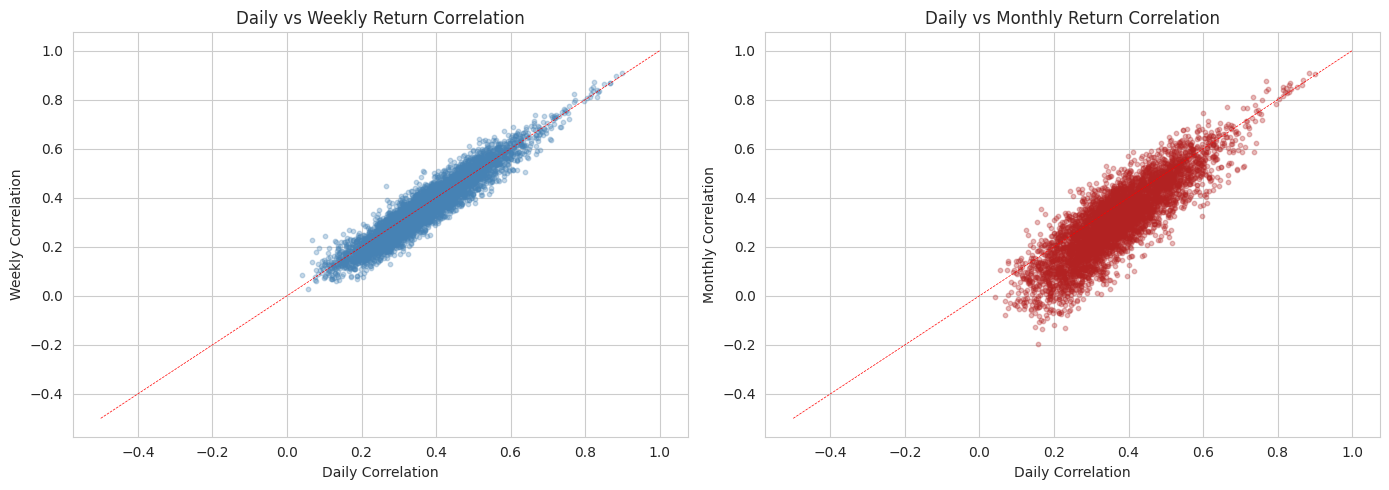

In [16]:
# Scatter plot: daily vs weekly correlation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(tf_df["Daily"], tf_df["Weekly"], alpha=0.3, s=10, color="steelblue")
axes[0].plot([-.5, 1], [-.5, 1], "r--", linewidth=0.5)
axes[0].set_xlabel("Daily Correlation")
axes[0].set_ylabel("Weekly Correlation")
axes[0].set_title("Daily vs Weekly Return Correlation")

axes[1].scatter(tf_df["Daily"], tf_df["Monthly"], alpha=0.3, s=10, color="firebrick")
axes[1].plot([-.5, 1], [-.5, 1], "r--", linewidth=0.5)
axes[1].set_xlabel("Daily Correlation")
axes[1].set_ylabel("Monthly Correlation")
axes[1].set_title("Daily vs Monthly Return Correlation")

plt.tight_layout()
plt.savefig("../outputs/timeframe_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary & Conclusions

### Key Findings:

1. **Correlated Pairs**: Several asset pairs exhibit high return correlations (ρ > 0.7), suggesting potential sector or theme overlap.

2. **Cointegration**: A subset of correlated pairs also show statistically significant cointegration (p < 0.05), meaning their price levels maintain a long-run equilibrium — the foundation of pairs trading.

3. **Lead-Lag**: Some pairs show significant cross-correlation at non-zero lags, indicating that one asset's movement can partially predict the other's future return.

4. **Cluster Structure**: PCA + K-Means reveals natural groupings among the 100 assets, likely corresponding to GICS sectors or industry groups in the underlying (anonymized) data.

5. **Multi-Timeframe**: Correlations tend to be stronger at longer timeframes (weekly, monthly), consistent with the idea that assets share common fundamental drivers that are more visible at lower frequencies.

### Integration into Main Portfolio:

The pairs/stat-arb signal can be incorporated as an additional alpha layer:
- Weight: 10-30% of total signal weight
- Benefits: diversifying vs. the directional momentum/ML signals
- Risk: regime breaks in cointegration relationships, convergence failure

$$w_i^{\text{total}} = 0.8 \cdot w_i^{\text{alpha}} + 0.2 \cdot w_i^{\text{stat-arb}}$$

This overlay adds a **relative-value** component to the portfolio, capturing alpha from mean-reversion in spreads while the main model captures **cross-sectional** alpha from momentum and ML predictions.
